# 심층 신경망

1. 심층 신경망(Deep Neural Network, DNN)
    - 입력층과 출력층 사이에 여러 개의 은닉층(hidden layer) 을 가진 인공 신경망 입니다.
    - 은닉층이 2개 이상 존재하는 신경망을 일반적으로 "심층(Deep) 신경망" 이라고 부릅니다.

2. 신경망의 기본 구조
    - 입력층(Input Layer) : 데이터가 처음 들어오는 곳입니다.
    - 은닉층(Hidden Layer) : 입력층과 출력층 사이에 존재하는 모든 층을 의미하며, 입력 데이터를 여러 단계로 변환하면서 데이터의 중요한 패턴(특성) 을 학습합니다.
    - 출력층(Output Layer) : 최종 예측 값을 내놓는 마지막 층입니다.

In [1]:
import tensorflow as tf

# TensorFlow / NumPy / Python에서 사용하는
# 난수 생성 시드(seed)를 42로 고정합니다.
# 같은 시드를 사용하면 난수 생성의 시작 상태가 동일해집니다.
tf.keras.utils.set_random_seed(42)

# GPU는 병렬 연산을 수행하기 때문에
# 연산 순서가 실행 시점마다 달라질 수 있습니다.
# 이로 인해 같은 코드라도 결과가 미세하게 달라지는
# 비결정적(non-deterministic) 연산이 발생할 수 있습니다.
# 따라서 시드를 고정하더라도 100% 동일한 결과가
# 항상 보장되지는 않습니다.

# TensorFlow 연산에서 발생하는 비결정성을 최소화하기 위해
# 가능한 한 연산 순서와 알고리즘을 고정하도록 설정합니다.
tf.config.experimental.enable_op_determinism()

 ---
데이터 가져오기

In [2]:
import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [3]:
from sklearn.model_selection import train_test_split

train_scaled = train_input / 255.0

train_scaled = train_scaled.reshape(-1, 28 * 28)

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

 ---
## 활성화 함수 (Activation Function)

- 층에서 계산된 선형 방정식 값($z$)을 비선형적인 신호로 변환하여 다음 층으로 전달하는 역할을 합니다.

1. 은닉층의 활성화 함수
    - 출력층에 비해 비교적 자유롭게 선택할 수 있으며, 대표적으로 다음과 같은 함수들을 사용합니다.
    - 시그모이드(Sigmoid) 함수 : 전통적인 함수로, 출력 값을 0~1 사이로 압축합니다.
    - 렐루(ReLU) 함수 : 현대 신경망에서 가장 선호되는 함수입니다. 0보다 큰 값은 그대로, 0보다 작은 값은 0으로 처리하여 연산 속도가 빠릅니다.

2. 출력층의 활성화 함수
    - 출력 층에 적용하는 활성화 함수는 해결하려는 문제의 종류에 따라 제한적으로 사용됩니다.
    - 이진 분류: 시그모이드(Sigmoid) 함수를 사용합니다.
    - 다중 분류: 소프트맥스(Softmax) 함수를 사용합니다.

 ---
### 사이킷런 vs 케라스 용어

| 의미 | 사이킷런(scikit-learn) 용어 | 케라스(Keras) 용어 |
| :--- | :--- | :--- |
| 손실 함수 | `loss` | `loss` (`model.compile()` 내에서 설정) |
| 반복 횟수 | `max_iter` | `epochs` |
| 평가 메서드 | `score()` | `evaluate()` |

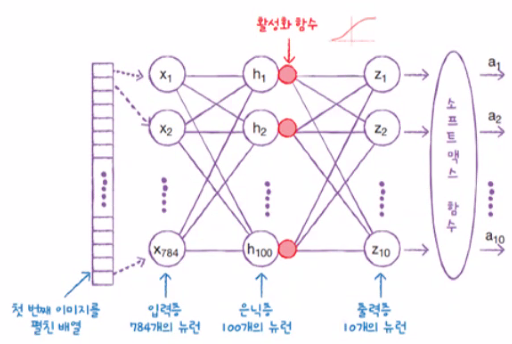

In [4]:
inputs = keras.layers.Input(shape=(784,))              # 입력층
dense1 = keras.layers.Dense(100, activation='sigmoid') # 은닉층
dense2 = keras.layers.Dense(10, activation='softmax')  # 출력층

 ---
### 심층 신경망(deep neural network, DNN) 만들기

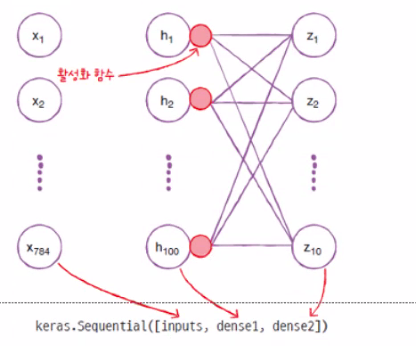

In [5]:
model = keras.Sequential([inputs, dense1, dense2])

In [6]:
model.summary()

# Model: "sequential"

# Output Shape
# (None, 100) : None은 배치 크기, 100은 해당 Dense 층의 뉴런 개수로 "배치 크기가 아직 정해지지 않은 상태에서, 각 샘플은 100차원 벡터로(100개의 값으로) 출력된다"라는 의미
#               Keras 모델은 배치 크기를 고정하지 않고 설계됨, batch_size는 학습 시 (model.fit) 정해집니다.
# Param # : 학습 과정에서 값이 조정되는 변수의 개수
# 학습 대상은 가중치와 편향입니다.
# 계산 공식 : ( 입력 뉴런 수 x 현재 층의 뉴런 수 ) + 현재 층의 절편 수
#      78500 = 784 * 100 + 100

# Trainable params : 학습 중 값이 업데이트 되는 파라미터
# Non-trainable params : 학습되지 않는 값, 고정된 가중치 등

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

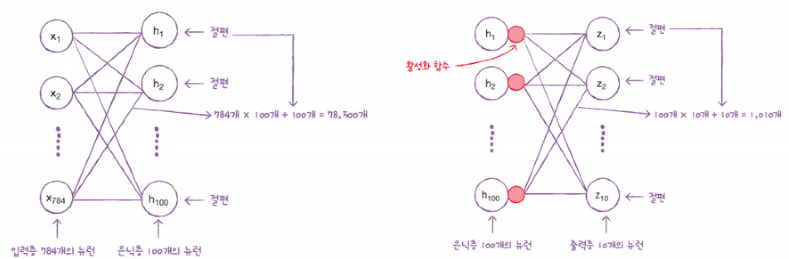

 ---
## 층을 추가하는 다른 방법

1. Sequential 클래스의 생성자에 레이어 객체들을 바로 전달해서 모델 객체를 한 번에 생성하는 방법

In [7]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(100, activation='sigmoid', name='은닉층'),
    keras.layers.Dense(10, activation='softmax', name='출력층')
], name='패션 MNIST 모델')

In [8]:
model.summary()

Model: "패션 MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 은닉층 (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 출력층 (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 ---
2. 많은 층을 추가하고자 할 때는 모델의 add() 메서드를 이용합니다.

In [9]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(784,)))
model.add(keras.layers.Dense(100, activation='sigmoid'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
# epochs=5는 48,000개의 데이터를 batch 단위로 묶어서 5번 반복 사용하며 학습한다는 뜻입니다.
# batch_size를 따로 지정하지 않으면 케라스는 기본적으로 32를 사용합니다.
model.fit(train_scaled, train_target, epochs=5)
# 전체 훈련 데이터: 60,000, 검증 데이터: 20% → 12,000, 실제 학습 데이터: 48,000

# 48,000 / 32(배치 사이즈) = 1500
# 1500/1500 : 한 epoch에서 총 1500개의 batch(미니배치)를 처리했다라는 의미입니다.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - accuracy: 0.8064 - loss: 0.5710
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 691us/step - accuracy: 0.8502 - loss: 0.4133
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.8620 - loss: 0.3769
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step - accuracy: 0.8713 - loss: 0.3531
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step - accuracy: 0.8781 - loss: 0.3352


 ---
### 렐루(ReLU) 함수의 특징 및 장점

- 기존 시그모이드 함수의 한계
    - 시그모이드 함수는 초창기 신경망의 은닉층 활성화 함수로 많이 사용되었습니다.
    - 하지만 입력값이 매우 크거나 매우 작아지면, 미분값(기울기)이 0에 가까워지는 문제가 발생합니다.
        - 시그모이드 함수는 모든 입력값을 0과 1 사이의 완만한 'S'자 곡선입니다.
        - 중앙 부분 ($z=0$ 부근): 그래프가 가파르기 때문에 기울기 값이 가장 큽니다
        - 양 끝 부분 (값이 매우 크거나 작을 때): 그래프가 거의 평평해집니다. 즉, 기울기가 0에 수렴합니다.
    - 이로 인해 앞쪽 층에서 전달된 기울기가 뒤쪽 층으로 갈수록 계속 작아지며, 결국 거의 0이 되어 학습이 제대로 이루어지지 않습니다.
    - 이러한 현상을 기울기 소실(Vanishing Gradient) 문제라고 합니다.
    - 특히 층이 많은 심층 신경망(Deep Neural Network) 일수록 이 문제가 누적되어 학습이 더욱 어려워집니다.

- 렐루(ReLU) 함수의 개선점
    - 동작 방식: 입력이 양수일 경우 마치 활성화 함수가 없는 것처럼 입력을 그대로 통과시키고, 음수일 경우에는 0으로 만듭니다. ReLU는 양수 구간에서 기울기가 1로 유지됩니다. 기울기가 깊은 층까지 잘 전달되어 심층 신경망에서도 학습이 안정적입니다.

    - 수식: $z > 0$이면 $z$를 출력하고, $z \leq 0$ 이면 0을 출력합니다.

    - $f(z) = \mathrm{max}(0, z)$

    - 현재 대부분의 딥러닝 모델에서 은닉층의 기본 활성화 함수로 사용됩니다.

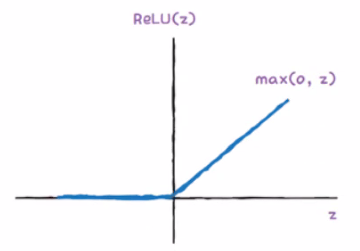

In [13]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

위에서는 아래 코드를 사용했지만

train_scaled = train_scaled.reshape(-1, 28 * 28)

위 코드가 지금은 필요가 없어 훈련 세트와 검증 세트 다시 만듭니다.

In [15]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [16]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.8113 - loss: 0.5291
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step - accuracy: 0.8581 - loss: 0.3915
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 713us/step - accuracy: 0.8729 - loss: 0.3529
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 701us/step - accuracy: 0.8817 - loss: 0.3288
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 701us/step - accuracy: 0.8878 - loss: 0.3131


In [17]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - accuracy: 0.8662 - loss: 0.3863


[0.38631802797317505, 0.8661666512489319]

 ---
## 옵티마이저 (Optimizer)

옵티마이저(최적화 알고리즘)는 손실 함수의 기울기(Gradient)를 이용해 가중치와 편향을 어떤 규칙으로, 얼마나 바꿀지를 결정합니다.

즉, "손실이 줄어드는 방향은 어디인가?", "한 번에 얼마나 이동할 것인가?"를 정하는 학습의 핵심 규칙입니다.

---

### 학습 프로세스와 옵티마이저의 역할

인공지능의 학습 단계 중 가중치를 실제로 수정하는 단계를 담당합니다.

입력 → 예측 → 손실 계산 → 기울기 계산 → 가중치 업데이트  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↑  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Optimizer가 담당

---

### 가중치 업데이트 수식

옵티마이저는 기울기($\frac{\partial Loss}{\partial w}$)를 받아서 아래와 같은 업데이틀르 수행합니다.

$$w \larr w - \eta \cdot \nabla J(w)$$

- $w$: 가중치 (Weight)

- $\eta$ (에타): 학습률 (Learning Rate)

- $\nabla J(w)$: 손실 함수의 기울기 (Gradient)

---

### 옵티마이저의 주요 질문

- 방향: 어느 쪽으로 가야 손실($Loss$)이 가장 빠르게 줄어드는가?
- 보폭: 학습률($\eta$)을 얼마나 크게 설정하여 이동할 것인가?

---

다양한 optimizer

| optimizer | 특징 | 핵심 전략 | 학습 결과 |
| :--- | :--- | :--- | :--- |
| SGD | 가장 기본적이면 계산이 단순함 | 경사 따라가기 | 속도가 느리고 구불구불하게 이동 |
| SGD + momentum | 관성을 이용해 가던 방향으로 가속 | 가속도 붙이기 | 진동이 줄어들고 직선적으로 빠르게 수렴 |
| RMSprop | 기울기에 따라 학습률을 유동적으로 조절 | 보폭 조절하기 | 가파른 곳에선 조심하고 완만한 곳에서는 속도를 냄 |
| Adam | 자동으로 학습률 조절, 가장 많이 사용 | 가속도 + 보폭 조절 | 가장 빠르고 안정적으로 최적점에 도달함

 ---
옵티마이저 설정 방법
1. optimizer = 'sgd' 지정

In [18]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

위와 동일한 코드

In [19]:
sgd = keras.optimizers.SGD()
model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

 ---
SGD 클래스의 학습률 기본값은 0.01 입니다. 이를 수정하는 방법입니다.

In [20]:
sgd = keras.optimizers.SGD(learning_rate=0.1)

 ---
기본 SGD에 모멘텀(가속)을 주어 속도를 높이고 네스테로프(예측)를 더해 정확도를 높이는 방법

In [21]:
sgd = keras.optimizers.SGD(
    momentum=0.9,   # [관성] 이전 이동 거리의 90%를 다음 이동에 반영합니다.
                    # 내리막길에서 가속도를 붙여 수렴 속도를 높이고,
                    # 작은 웅덩이(Local Minimum)를 관성으로 돌파하게 도와줍니다.

    nesterov=True   # [네스테로프 가속 경사] 관성에 의해 이동할 '미래 위치'의
                    # 기울기를 미리 확인하여 업데이트합니다.
                    # 관성 때문에 목표지점을 휙 지나쳐버리는(Overshooting) 현상을
                    # 방지하여 기본 모멘텀보다 훨씬 안정적으로 멈추게 합니다.
)

 ---
아다그라드의 핵심 전략은 맞춤형 보폭 조절입니다.

학습률(Learning Rate)을 모든 매개변수에 똑같이 적용하지 말고, 각자 상황에 맞춰서 다르게 조절합니다.

별도의 설정이 없으면 기본 학습률($0.01$)에서 시작하여 학습이 진행될수록 스스로 줄여나갑니다.

In [22]:
adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

 ---
Adagrad는 과거의 모든 기울기를 다 더해서 보폭을 줄였기 때문에, 학습이 길어지면 보폭이 너무 작아져서 결국 학습이 멈춰버리는(0이 되는) 문제가 있었습니다.

RMSprop은 너무 먼 과거의 기울기는 잊어버리고, 최근의 기울기 변화 위주로 보폭을 조절합니다.

- 케라스의 기본 옵티마이저가 RMSprop 입니다.

In [23]:
rmsprop = keras.optimizers.RMSprop()
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

 ---
optimizer='adam'를 이용한 모델 생성

In [24]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [25]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - accuracy: 0.8154 - loss: 0.5262
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 747us/step - accuracy: 0.8576 - loss: 0.3955
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 748us/step - accuracy: 0.8723 - loss: 0.3513
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 742us/step - accuracy: 0.8829 - loss: 0.3230
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step - accuracy: 0.8905 - loss: 0.3017


In [26]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.8751 - loss: 0.3442


[0.34416502714157104, 0.875083327293396]